In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

plt.style.use("default")

In [20]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [21]:
df.columns


Index(['Date', 'Price'], dtype='str')

In [22]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y", errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df = df.dropna(subset=["Date", "Price"])
df = df.sort_values("Date")
df = df.set_index("Date")

df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [23]:
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of rows:", len(df))

Start date: 1987-05-20 00:00:00
End date: 2020-04-21 00:00:00
Number of rows: 8360


In [24]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8360 entries, 1987-05-20 to 2020-04-21
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   8360 non-null   float64
dtypes: float64(1)
memory usage: 130.6 KB


In [25]:
df.describe()

,Price
count,8360.000000
mean,46.459669
std,32.504671
min,9.100000
25%,18.780000
50%,31.750000
75%,67.042500
max,143.950000


In [26]:
df.isnull().sum()

Price    0
dtype: int64

In [27]:
df.to_csv("../data/processed/brent_oil_prices_cleaned.csv")

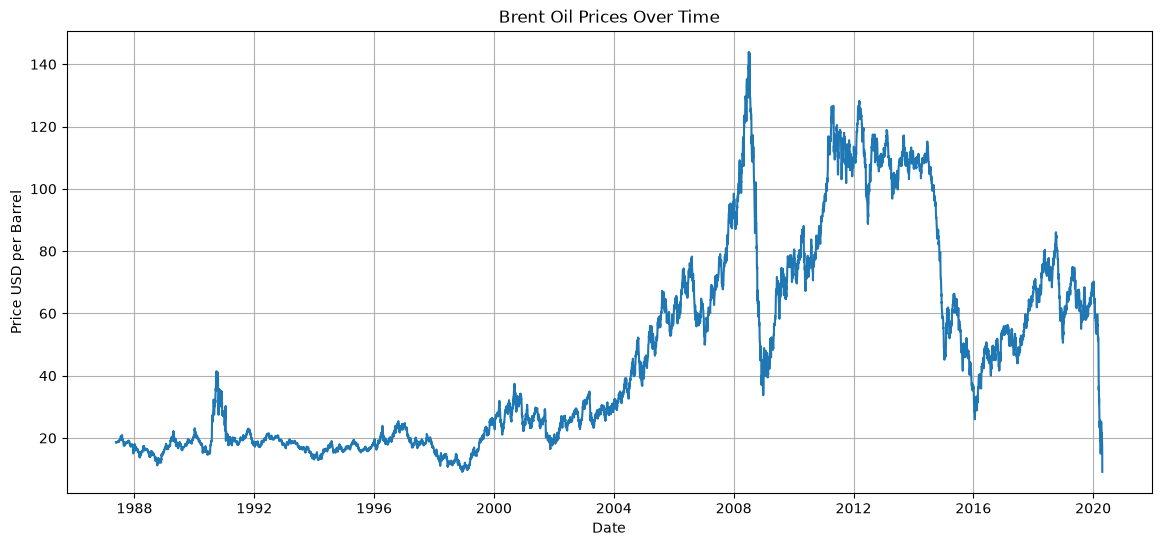

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Price"])
plt.title("Brent Oil Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price USD per Barrel")
plt.grid(True)
plt.savefig("../reports/brent_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

The Brent oil price series shows several major periods of increase, decline, and high volatility. These movements suggest that oil prices are affected by global economic cycles, supply shocks, geopolitical conflicts, and policy decisions.

In [29]:
df["Log_Price"] = np.log(df["Price"])
df["Log_Return"] = df["Log_Price"].diff()

df = df.dropna()

df.head()

,Price,Log_Price,Log_Return
Date,,,
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612
1987-05-27,18.60,2.923162,-0.001612


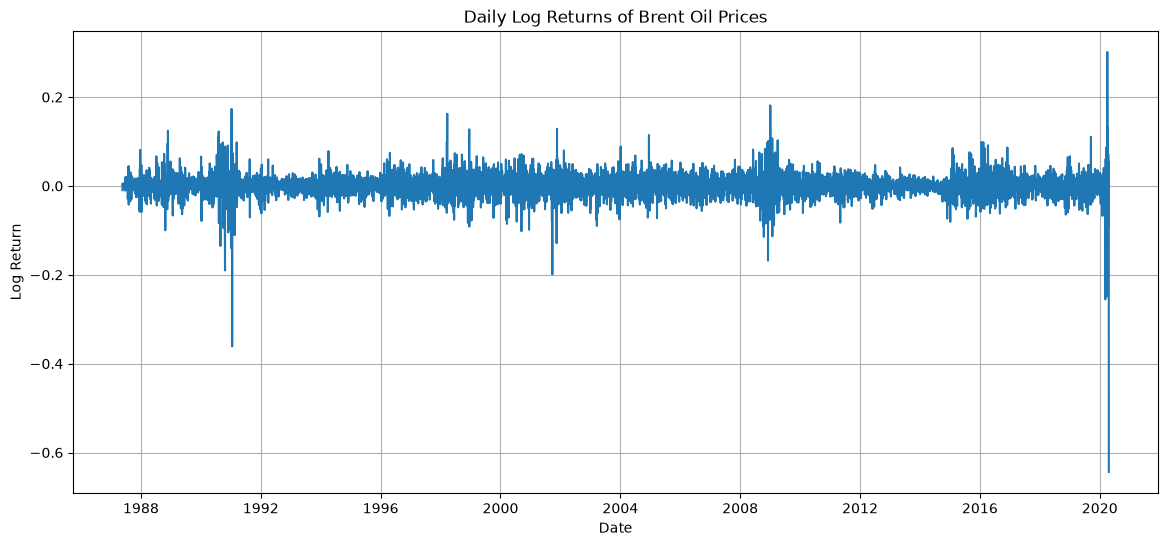

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Log_Return"])
plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.savefig("../reports/brent_log_returns.png", dpi=300, bbox_inches="tight")
plt.show()

The log return plot shows periods of volatility clustering, where large positive and negative changes occur close together. This is common in financial and commodity markets, especially around crises and major policy shocks.

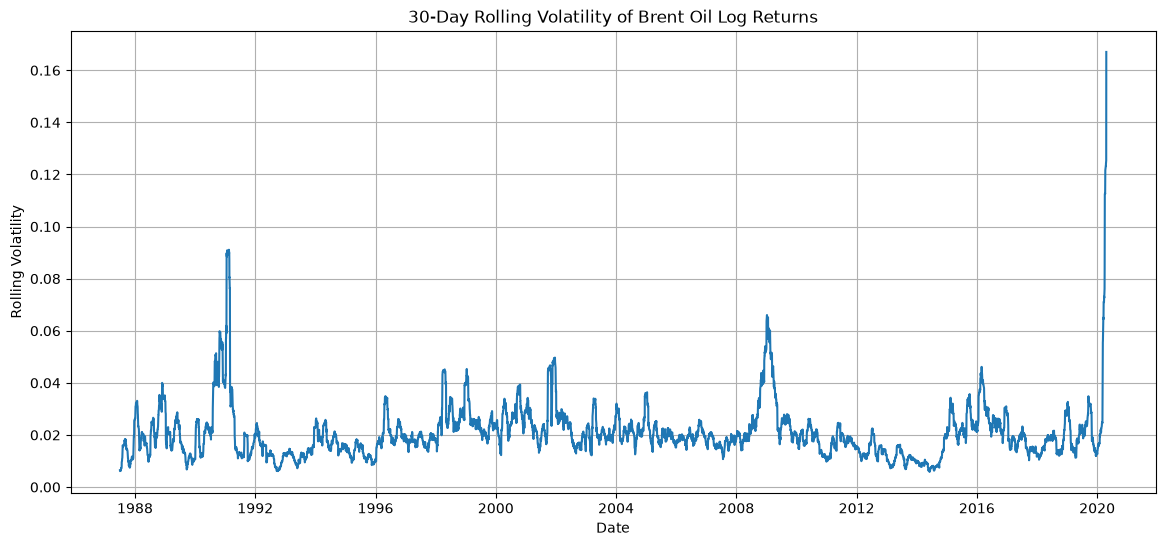

In [31]:
df["Rolling_Volatility_30"] = df["Log_Return"].rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Rolling_Volatility_30"])
plt.title("30-Day Rolling Volatility of Brent Oil Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.savefig("../reports/brent_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

Rolling volatility helps identify periods when the oil market became more unstable. High volatility periods may correspond to wars, financial crises, OPEC decisions, sanctions, or global demand shocks.

In [32]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    if result[1] < 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-stationary")

In [33]:
adf_test(df["Price"], "Brent Oil Price")

ADF Test for Brent Oil Price
ADF Statistic: -2.016867290028986
p-value: 0.27922670050611254
Result: Non-stationary


In [34]:
adf_test(df["Log_Return"], "Brent Oil Log Returns")

ADF Test for Brent Oil Log Returns
ADF Statistic: -12.603088598261774
p-value: 1.719110914308765e-23
Result: Stationary


The raw Brent oil price series is likely non-stationary because commodity prices often show long-term trends and structural shifts. The log return series is expected to be more stationary because it measures daily percentage-like changes rather than the price level itself. This supports using log returns for volatility analysis and considering change point models to detect structural breaks.

In [35]:
events = pd.read_csv("../data/events/oil_market_events.csv")
events["date"] = pd.to_datetime(events["date"])

events.head()

,date,event,category,expected_market_effect,notes
0,1990-08-02,Iraq invades Kuwait,Geopolitical conflict,Price increase,Gulf War supply fear and regional instability
1,1991-01-17,Operation Desert Storm begins,Geopolitical conflict,High volatility,Military action in oil-producing region
2,1997-07-02,Asian financial crisis begins,Economic shock,Price decline,Lower demand expectations from Asian economies
3,2001-09-11,September 11 attacks,Geopolitical shock,High volatility,Global uncertainty and demand concerns
4,2003-03-20,Iraq War begins,Geopolitical conflict,Price increase,Supply risk and Middle East instability


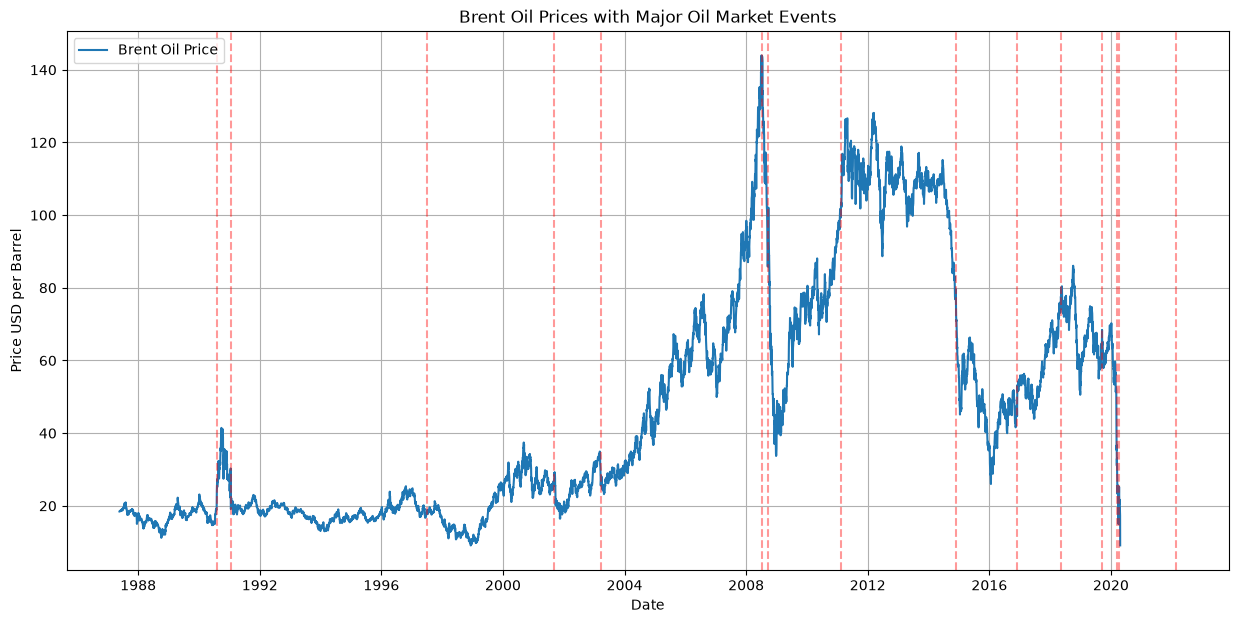

In [36]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df["Price"], label="Brent Oil Price")

for _, row in events.iterrows():
    plt.axvline(row["date"], color="red", linestyle="--", alpha=0.4)

plt.title("Brent Oil Prices with Major Oil Market Events")
plt.xlabel("Date")
plt.ylabel("Price USD per Barrel")
plt.grid(True)
plt.legend()
plt.savefig("../reports/brent_prices_with_events.png", dpi=300, bbox_inches="tight")
plt.show()